# Nuclear Data — Visualisations and Counterfactual Analysis

This notebook produces 9 charts from the SQLite database () and the raw OWID CSV files.

The analysis progresses through four stages:
1. **Global rankings** — which countries have produced the most nuclear electricity historically
2. **Italy** — its nuclear history, the 1987 referendum, and what replaced nuclear in the energy mix
3. **International comparisons** — France vs Germany as a geopolitical contrast
4. **Counterfactual analysis** — three benchmark scenarios and one realistic scenario (Montalto di Castro) estimating what Italy could have produced, and how much gas and CO₂ it would have avoided

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os
import logging

# Logging setup (force=True for Jupyter kernel compatibility)
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s — %(levelname)s — %(message)s',
    force=True
)
logger = logging.getLogger(__name__)

# Connect to database
BASE_DIR = os.path.dirname(os.path.abspath(''))
DB_PATH = os.path.join(BASE_DIR, 'db', 'nuclear.db')
conn = sqlite3.connect(DB_PATH)

# Chart style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

logger.info("Setup complete")
logger.info(f"Database: {DB_PATH}")

2026-05-07 17:55:27,116 — INFO — Setup complete
2026-05-07 17:55:27,116 — INFO — Database: C:\Users\giuse\documents\nuclear-data-analysis\db\nuclear.db


## 1. Global Rankings

The first chart ranks all nuclear-producing countries by their historical average output (TWh). Data is loaded directly from the SQLite DB via the  table. This establishes the global scale before narrowing the focus to individual countries.

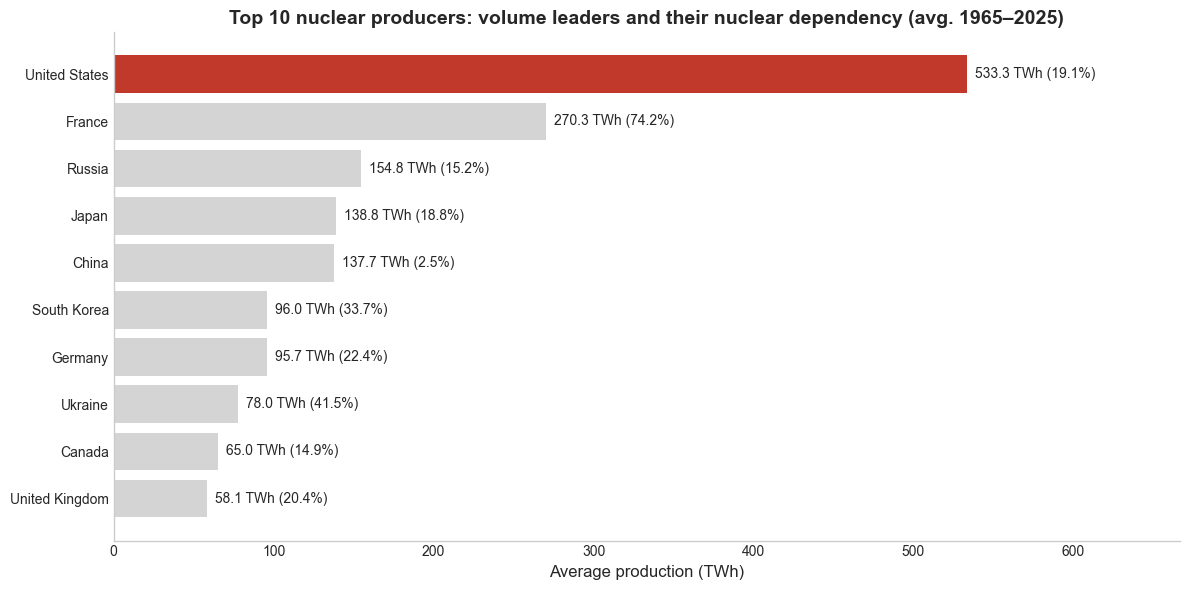

2026-05-07 17:55:27,422 — INFO — Chart saved to plots/


In [2]:
# Load data from database
query = """
    SELECT g.country, 
       ROUND(AVG(g.nuclear_twh), 1) as avg_twh,
       ROUND(AVG(i.nuclear_share_elec), 1) as avg_share
FROM nuclear_generation g
LEFT JOIN nuclear_indicators i ON g.country = i.country AND g.year = i.year
WHERE g.nuclear_twh > 0
GROUP BY g.country
ORDER BY avg_twh DESC
LIMIT 10
"""
df_top10 = pd.read_sql(query, conn)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(df_top10['country'], df_top10['avg_twh'],
               color=['#c0392b' if country == 'United States' else '#d4d4d4'
                      for country in df_top10['country']])

# Value labels on bars
for bar, (_, row) in zip(bars, df_top10.iterrows()):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{row["avg_twh"]} TWh ({row["avg_share"]}%)',
            va='center', fontsize=10)
ax.set_xlabel('Average production (TWh)', fontsize=12)
ax.set_title('Top 10 nuclear producers: volume leaders and their nuclear dependency (avg. 1965–2025)',
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
ax.set_xlim(0, df_top10['avg_twh'].max() * 1.25)
plt.tight_layout()
plt.savefig('../plots/01_top10_producers.png', dpi=150, bbox_inches='tight')
plt.show()




logger.info("Chart saved to plots/")

## 2. Italy — Nuclear History (1965–2025)

Italy is one of the few countries to have dismantled an existing nuclear programme following a public referendum. This section traces Italian production year by year, then zooms out to compare the trajectory of the top 5 global producers — contextualising how marginal Italy's nuclear output was relative to the world leaders.

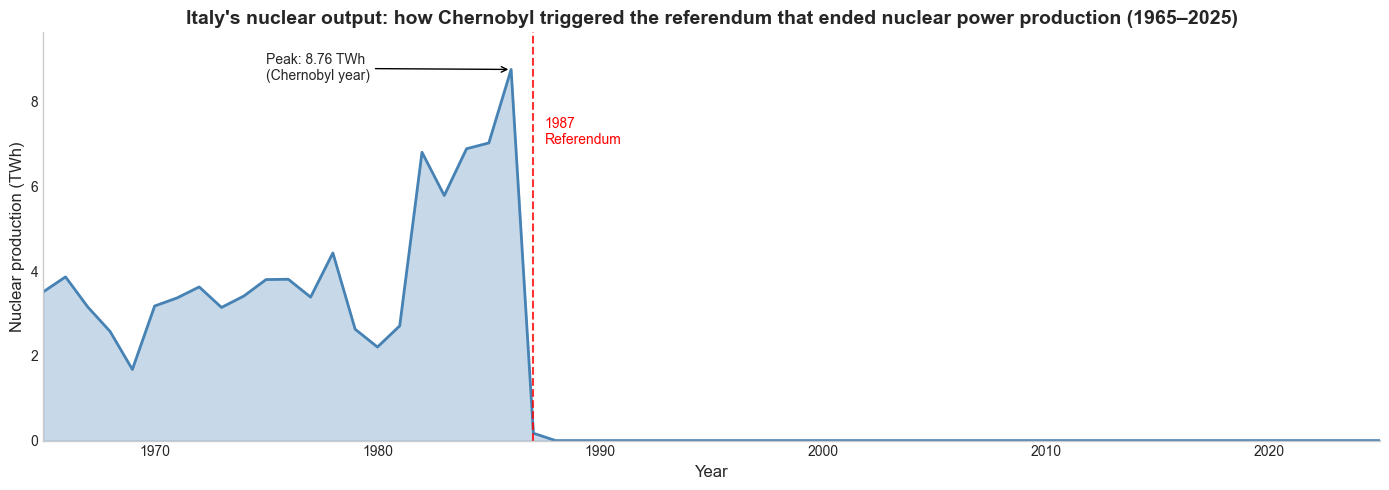

2026-05-07 17:55:27,597 — INFO — Chart saved to plots/


In [3]:
query = """
    SELECT year, nuclear_twh
    FROM nuclear_generation
    WHERE country = 'Italy'
    ORDER BY year
"""
df_italy = pd.read_sql(query, conn)

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(df_italy['year'], df_italy['nuclear_twh'],
                alpha=0.3, color='steelblue')
ax.plot(df_italy['year'], df_italy['nuclear_twh'],
        color='steelblue', linewidth=2)
ax.set_ylim(0, df_italy['nuclear_twh'].max() * 1.1)
ax.set_xlim(df_italy['year'].min(), df_italy['year'].max())
# Referendum vertical line
ax.axvline(x=1987, color='red', linestyle='--', linewidth=1.5, alpha=0.8, ymin=0)
ax.text(1987.5, 7, '1987\nReferendum', color='red', fontsize=10)

# Peak annotation
ax.annotate('Peak: 8.76 TWh\n(Chernobyl year)',
            xy=(1986, 8.758), xytext=(1975, 8.5),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Nuclear production (TWh)', fontsize=12)
ax.set_title('Italy\'s nuclear output: how Chernobyl triggered the referendum that ended nuclear power production (1965–2025)',
             fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.savefig('../plots/02_italy_history.png', dpi=150, bbox_inches='tight')
plt.show()
logger.info("Chart saved to plots/")

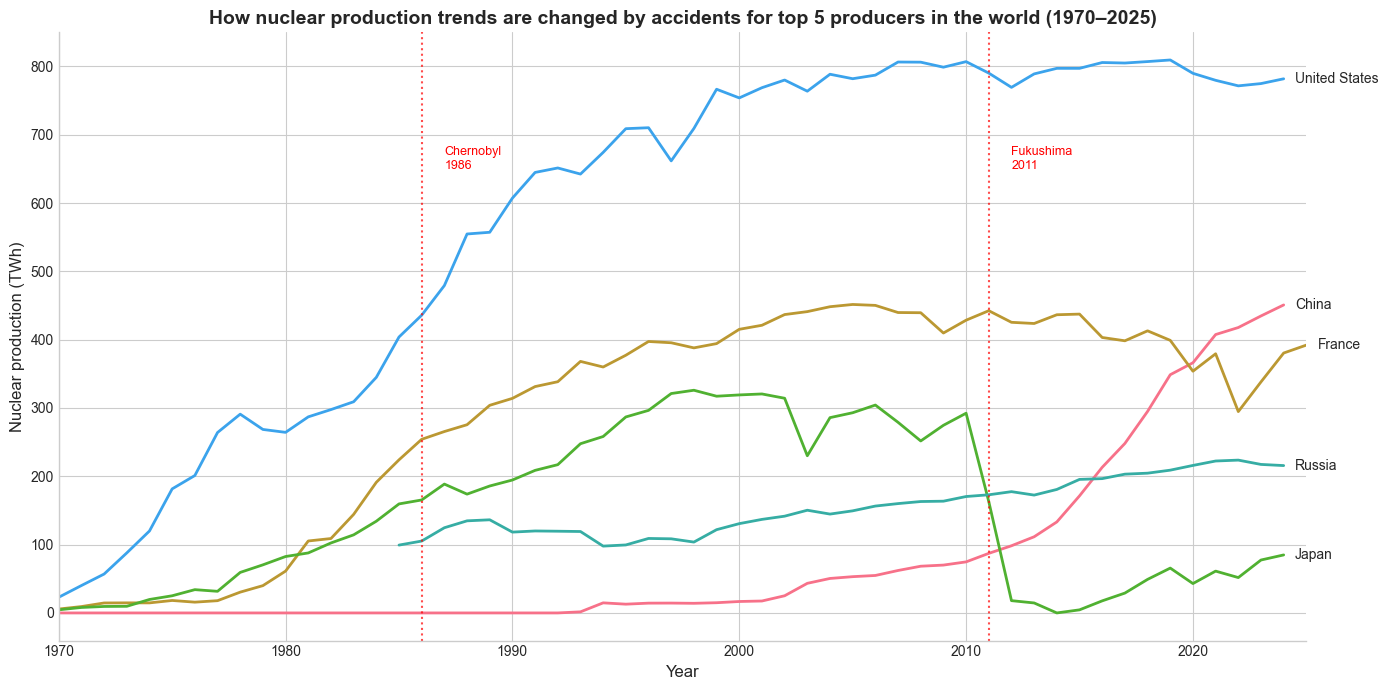

2026-05-07 17:55:27,818 — INFO — Chart saved to plots/


In [4]:
query = """
    SELECT country, year, nuclear_twh
    FROM nuclear_generation
    WHERE country IN ('United States', 'France', 'Russia', 'China', 'Japan')
    AND year >= 1970
    ORDER BY country, year
"""
df_trend = pd.read_sql(query, conn)

fig, ax = plt.subplots(figsize=(14, 7))

for country in df_trend['country'].unique():
    df_c = df_trend[df_trend['country'] == country]
    ax.plot(df_c['year'], df_c['nuclear_twh'], linewidth=2, label=country)
    ax.text(df_c['year'].iloc[-1] + 0.5, df_c['nuclear_twh'].iloc[-1], 
        country, va='center', fontsize=10)
# Chernobyl line
ax.axvline(x=1986, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(1987, 650, 'Chernobyl\n1986', color='red', fontsize=9)

# Fukushima line
ax.axvline(x=2011, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(2012, 650, 'Fukushima\n2011', color='red', fontsize=9)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Nuclear production (TWh)', fontsize=12)
ax.set_title('How nuclear production trends are changed by accidents for top 5 producers in the world (1970–2025)',
             fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(1970, df_trend['year'].max())
plt.tight_layout()
plt.savefig('../plots/03_top5_trend.png', dpi=150, bbox_inches='tight')
plt.show()
logger.info("Chart saved to plots/")

## 3. Italy — Energy Mix and the Post-Referendum Transition

After the 1987 referendum, Italy shut down its last plant (Caorso) and phased out nuclear entirely by 1990. This section analyses what replaced it in the electricity mix and quantifies the growth in gas consumption in the two decades that followed, using the full OWID dataset.

In [5]:
query = """
    SELECT year, nuclear_electricity, nuclear_share_elec,
           nuclear_share_energy, population
    FROM nuclear_indicators
    WHERE country = 'Italy'
    ORDER BY year
"""
df_italy_ind = pd.read_sql(query, conn)

logger.info(f"Available years: {df_italy_ind['year'].min()} - {df_italy_ind['year'].max()}")
logger.info(f"Total rows: {len(df_italy_ind)}")
logger.info("First rows with non-null data:")
display(df_italy_ind[df_italy_ind['nuclear_share_elec'].notna()].head(10))

2026-05-07 17:55:27,827 — INFO — Available years: 1900 - 2025
2026-05-07 17:55:27,827 — INFO — Total rows: 126
2026-05-07 17:55:27,828 — INFO — First rows with non-null data:


,year,nuclear_electricity,nuclear_share_elec,nuclear_share_energy,population
85,1985,7.024,3.782,1.197,56855499.0
86,1986,8.758,4.554,1.453,56875982.0
87,1987,0.174,0.086,0.028,56891919.0
88,1988,0.000,0.000,0.000,56928748.0
89,1989,0.000,0.000,0.000,56976750.0
90,1990,0.000,0.000,0.000,57031457.0
91,1991,0.000,0.000,0.000,57075394.0
92,1992,0.000,0.000,0.000,57124993.0
93,1993,0.000,0.000,0.000,57170762.0
94,1994,0.000,0.000,0.000,57420136.0


In [6]:
# Reload full CSV — contains all energy sources
df_owid = pd.read_csv('../data/raw/owid-energy-data.csv')

# Filter Italy only
cols_italia = ['year', 'nuclear_electricity', 'coal_electricity',
               'gas_electricity', 'oil_electricity', 'hydro_electricity',
               'solar_electricity', 'wind_electricity',
               'renewables_electricity', 'electricity_generation']

df_it = df_owid[df_owid['country'] == 'Italy'][cols_italia].copy()
df_it = df_it[df_it['year'] >= 1965].sort_values('year')

logger.info(f"Available years: {df_it['year'].min()} - {df_it['year'].max()}")
logger.info("First rows:")
display(df_it[df_it['electricity_generation'].notna()].head(10))

2026-05-07 17:55:27,923 — INFO — Available years: 1965 - 2025
2026-05-07 17:55:27,924 — INFO — First rows:


,year,nuclear_electricity,coal_electricity,gas_electricity,oil_electricity,hydro_electricity,solar_electricity,wind_electricity,renewables_electricity,electricity_generation
10345,1985,7.024,30.023,24.712,76.174,41.092,0.000,0.000,43.928,185.740
10346,1986,8.758,31.004,26.871,77.483,41.096,0.000,0.000,44.121,192.330
10347,1987,0.174,33.035,31.732,89.941,39.505,0.000,0.000,42.748,201.372
10348,1988,0.000,33.897,32.420,89.702,40.676,0.000,0.000,44.015,203.561
10349,1989,0.000,31.867,34.407,102.784,34.057,0.002,0.002,37.393,210.750
10350,1990,0.000,32.050,39.710,106.490,31.630,0.000,0.000,34.900,213.150
10351,1991,0.000,28.500,36.340,108.060,42.240,0.000,0.000,45.530,218.430
10352,1992,0.000,21.360,35.480,120.070,42.200,0.010,0.000,45.770,222.680
10353,1993,0.000,16.660,39.960,117.900,41.420,0.010,0.000,45.220,219.740
10354,1994,0.000,19.860,40.800,119.840,44.660,0.010,0.010,48.250,228.750


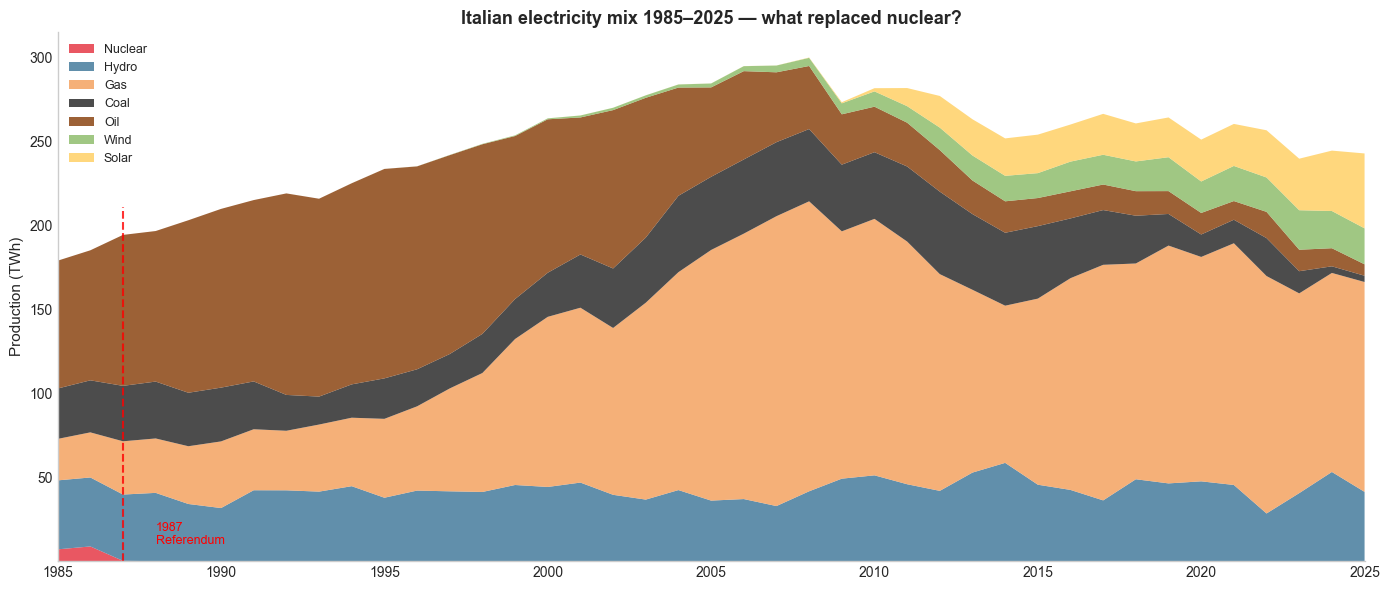

2026-05-07 17:55:28,157 — INFO — Chart saved to plots/


In [7]:
df_plot = df_it[df_it['electricity_generation'].notna()].copy()

fig, ax1 = plt.subplots(1, 1, figsize=(14, 6))

# --- Top chart: electricity mix area chart ---

ax1.stackplot(df_plot['year'],
              df_plot['nuclear_electricity'].fillna(0),
              df_plot['hydro_electricity'].fillna(0),
              df_plot['gas_electricity'].fillna(0),
              df_plot['coal_electricity'].fillna(0),
              df_plot['oil_electricity'].fillna(0),
              df_plot['wind_electricity'].fillna(0),
              df_plot['solar_electricity'].fillna(0),
              labels=['Nuclear', 'Hydro', 'Gas', 'Coal', 'Oil', 'Wind', 'Solar'],
              colors=['#e63946', '#457b9d', '#f4a261', '#2d2d2d', '#8B4513', '#90be6d', '#ffd166'],
              alpha=0.85)

ax1.axvline(x=1987, color='red', linestyle='--', linewidth=1.5, alpha=0.8, ymax=0.67)
ax1.text(1988, 10, '1987\nReferendum', color='red', fontsize=9)
ax1.set_ylabel('Production (TWh)', fontsize=11)
ax1.set_title('Italian electricity mix 1985–2025 — what replaced nuclear?',
              fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(False)
ax1.set_xlim(1985, df_trend['year'].max())
ax1.yaxis.get_major_ticks()[0].set_visible(False)
plt.tight_layout()
plt.savefig('../plots/02b_italy_energy_mix.png', dpi=150, bbox_inches='tight')
plt.show()
logger.info("Chart saved to plots/")

In [8]:
query = """
    SELECT
        CASE WHEN year <= 1987 THEN 'Before (1985–1987)'
             WHEN year >= 2000 THEN 'After (2000–2010)'
             ELSE NULL END as period,
        ROUND(AVG(nuclear_twh), 2) as avg_nuclear
    FROM nuclear_generation
    WHERE country = 'Italy'
    AND (year <= 1987 OR (year >= 2000 AND year <= 2010))
    GROUP BY period
"""
df_confronto = pd.read_sql(query, conn)
display(df_confronto)

# Compute gas growth from OWID CSV
gas_prima = df_it[df_it['year'] <= 1987]['gas_electricity'].mean()
gas_dopo = df_it[(df_it['year'] >= 2000) & (df_it['year'] <= 2010)]['gas_electricity'].mean()
oil_prima = df_it[df_it['year'] <= 1987]['oil_electricity'].mean()
oil_dopo = df_it[(df_it['year'] >= 2000) & (df_it['year'] <= 2010)]['oil_electricity'].mean()

logger.info(f"Gas — before: {gas_prima:.1f} TWh → after: {gas_dopo:.1f} TWh (+{gas_dopo-gas_prima:.1f} TWh)")
logger.info(f"Oil — before: {oil_prima:.1f} TWh → after: {oil_dopo:.1f} TWh (+{oil_dopo-oil_prima:.1f} TWh)")

,period,avg_nuclear
0,After (2000–2010),0.00
1,Before (1985–1987),3.91


2026-05-07 17:55:28,166 — INFO — Gas — before: 27.8 TWh → after: 136.8 TWh (+109.1 TWh)
2026-05-07 17:55:28,166 — INFO — Oil — before: 81.2 TWh → after: 59.8 TWh (+-21.4 TWh)


## 4. France vs Germany — Two Opposite Choices

A direct comparison of the two largest European economies: France expanded its nuclear fleet aggressively through the 1970s–80s and today generates ~70% of its electricity from nuclear. Germany chose the opposite path — building and then dismantling its fleet, with the last reactor shut down in 2023. This contrast provides geopolitical and energy-security context for the Italian case.

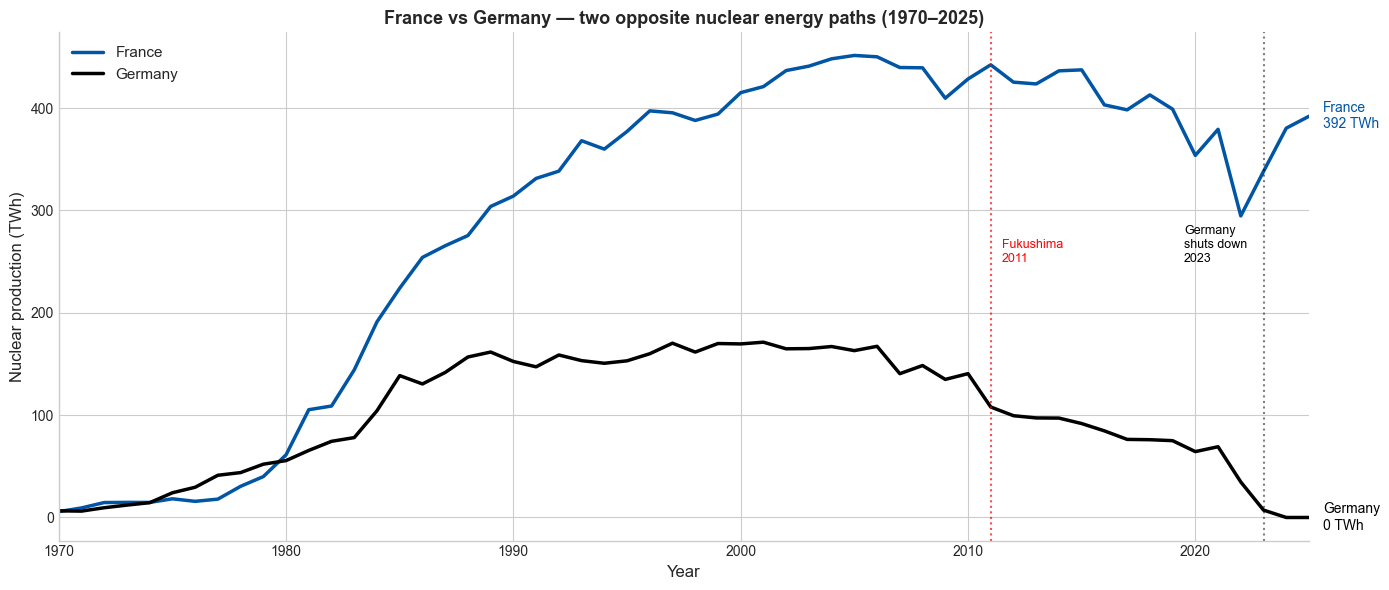

2026-05-07 17:55:28,381 — INFO — Chart saved to plots/


In [9]:
query = """
    SELECT country, year, nuclear_twh
    FROM nuclear_generation
    WHERE country IN ('France', 'Germany')
    AND year >= 1970
    ORDER BY country, year
"""
df_frvde = pd.read_sql(query, conn)

fig, ax = plt.subplots(figsize=(14, 6))

for country, color in [('France', '#0055A4'), ('Germany', '#000000')]:
    df_c = df_frvde[df_frvde['country'] == country]
    ax.plot(df_c['year'], df_c['nuclear_twh'],
            linewidth=2.5, label=country, color=color)
    # Final value label
    last = df_c.iloc[-1]
    ax.annotate(f"{country}\n{last['nuclear_twh']:.0f} TWh",
                xy=(last['year'], last['nuclear_twh']),
                xytext=(10, 0), textcoords='offset points',
                fontsize=10, color=color, va='center')

# Fukushima event
ax.axvline(x=2011, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(2011.5, 250, 'Fukushima\n2011', color='red', fontsize=9)

# German Energiewende
ax.axvline(x=2023, color='black', linestyle=':', linewidth=1.5, alpha=0.5)
ax.text(2019.5, 250, 'Germany\nshuts down\n2023', color='black', fontsize=9)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Nuclear production (TWh)', fontsize=12)
ax.set_title('France vs Germany — two opposite nuclear energy paths (1970–2025)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(1970, df_trend['year'].max())
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../plots/04_france_vs_germany.png', dpi=150, bbox_inches='tight')
plt.show()
logger.info("Chart saved to plots/")

## 5. Counterfactual Analysis — What If Italy Had Kept Nuclear?

We construct three benchmark scenarios by scaling the post-1986 trajectories of comparable countries (South Africa, Finland, Hungary) to Italy's actual 1986 production level of 8.76 TWh. The section covers the baseline data (nuclear share and TWh in 1986–1987), the scaling methodology, CO₂ emission factors (490 g/kWh for gas vs 12 g/kWh for nuclear), and the estimated gas displacement and CO₂ savings under each scenario.

In [10]:
query = """
    SELECT country,
           ROUND(nuclear_share_elec, 2) as share_1987
    FROM nuclear_indicators
    WHERE year = 1987
    AND nuclear_share_elec > 0
    ORDER BY share_1987 ASC
"""
df_benchmark = pd.read_sql(query, conn)
logger.info("Countries with nuclear share data in 1987:")
display(df_benchmark)

2026-05-07 17:55:28,386 — INFO — Countries with nuclear share data in 1987:


,country,share_1987
0,Italy,0.09
1,Brazil,0.48
2,Pakistan,0.84
3,India,2.38
4,South Africa,4.05
5,Netherlands,5.20
6,Russia,11.91
7,Argentina,12.40
8,Canada,15.56
9,Czechia,17.20


In [11]:
query = """
    SELECT country,
           ROUND(nuclear_share_elec, 2) as share_1986
    FROM nuclear_indicators
    WHERE year = 1986
    AND nuclear_share_elec > 0
    ORDER BY share_1986 ASC
"""
df_benchmark = pd.read_sql(query, conn)
logger.info("Countries with nuclear share data in 1986:")
display(df_benchmark)

2026-05-07 17:55:28,394 — INFO — Countries with nuclear share data in 1986:


,country,share_1986
0,Brazil,0.07
1,Pakistan,1.63
2,India,2.48
3,Italy,4.55
4,South Africa,5.94
5,Netherlands,6.28
6,Czechia,10.15
7,Russia,10.51
8,Argentina,11.65
9,Canada,15.21


In [12]:
query = """
    SELECT country, ROUND(nuclear_twh, 2) as twh_1986
    FROM nuclear_generation
    WHERE year = 1986
    AND nuclear_twh > 0
    ORDER BY twh_1986 ASC
"""
df_twh86 = pd.read_sql(query, conn)
logger.info("Absolute nuclear production in 1986 (TWh):")
display(df_twh86)

2026-05-07 17:55:28,403 — INFO — Absolute nuclear production in 1986 (TWh):


,country,twh_1986
0,Brazil,0.14
1,Pakistan,0.53
2,Netherlands,4.22
3,India,5.02
4,Argentina,5.71
5,Czechia,6.15
6,Hungary,7.42
7,Italy,8.76
8,South Africa,8.80
9,Lithuania,9.88


In [13]:
query = """
    SELECT country, year, nuclear_twh
    FROM nuclear_generation
    WHERE country IN ('Italy', 'South Africa', 'Hungary', 'Finland')
    AND year >= 1980
    ORDER BY country, year
"""
df_cf = pd.read_sql(query, conn)

# Verify data
for country in ['Italy', 'South Africa', 'Hungary', 'Finland']:
    df_c = df_cf[df_cf['country'] == country]
    logger.info(f"{country}: {df_c['year'].min()}-{df_c['year'].max()} | "
                f"1986: {df_c[df_c['year']==1986]['nuclear_twh'].values[0]:.2f} TWh | "
                f"2023: {df_c[df_c['year']==2023]['nuclear_twh'].values[0]:.2f} TWh")

2026-05-07 17:55:28,415 — INFO — Italy: 1980-2025 | 1986: 8.76 TWh | 2023: 0.00 TWh
2026-05-07 17:55:28,416 — INFO — South Africa: 1980-2024 | 1986: 8.80 TWh | 2023: 8.10 TWh
2026-05-07 17:55:28,418 — INFO — Hungary: 1980-2025 | 1986: 7.42 TWh | 2023: 15.92 TWh
2026-05-07 17:55:28,419 — INFO — Finland: 1980-2025 | 1986: 18.95 TWh | 2023: 34.31 TWh


In [14]:
# Reload df_paesi from database
query = """
    SELECT country, iso_code, year, nuclear_twh
    FROM nuclear_generation
"""
df_paesi = pd.read_sql(query, conn)
logger.info(f"df_paesi: {len(df_paesi)} rows")
display(df_paesi.head())

2026-05-07 17:55:28,433 — INFO — df_paesi: 8215 rows


,country,iso_code,year,nuclear_twh
0,Afghanistan,AFG,2000,0.0
1,Afghanistan,AFG,2001,0.0
2,Afghanistan,AFG,2002,0.0
3,Afghanistan,AFG,2003,0.0
4,Afghanistan,AFG,2004,0.0


In [15]:
# Reload the full CSV
df_owid_full = pd.read_csv('../data/raw/owid-energy-data.csv')

# Select required columns
cols = ['country', 'year', 'gas_electricity',
        'coal_electricity', 'oil_electricity',
        'electricity_generation', 'greenhouse_gas_emissions']

df_energy = df_owid_full[cols].copy()

# Merge nuclear_generation with energy data
# on=['country','year']: join where both country AND year match
# how='left': keep all rows from df_paesi
df_merged = df_paesi.merge(df_energy, on=['country', 'year'], how='left')

logger.info(f"df_paesi:  {len(df_paesi)} rows, {len(df_paesi.columns)} columns")
logger.info(f"df_energy: {len(df_energy)} rows, {len(df_energy.columns)} columns")
logger.info(f"df_merged: {len(df_merged)} rows, {len(df_merged.columns)} columns")
logger.info(f"Resulting columns: {list(df_merged.columns)}")
logger.info("First rows for Italy:")
display(df_merged[df_merged['country'] == 'Italy'].head(10))

2026-05-07 17:55:28,567 — INFO — df_paesi:  8215 rows, 4 columns
2026-05-07 17:55:28,568 — INFO — df_energy: 23232 rows, 7 columns
2026-05-07 17:55:28,569 — INFO — df_merged: 8215 rows, 9 columns
2026-05-07 17:55:28,569 — INFO — Resulting columns: ['country', 'iso_code', 'year', 'nuclear_twh', 'gas_electricity', 'coal_electricity', 'oil_electricity', 'electricity_generation', 'greenhouse_gas_emissions']
2026-05-07 17:55:28,570 — INFO — First rows for Italy:


,country,iso_code,year,nuclear_twh,gas_electricity,coal_electricity,oil_electricity,electricity_generation,greenhouse_gas_emissions
3742,Italy,ITA,1965,3.510,NaN,NaN,NaN,NaN,NaN
3743,Italy,ITA,1966,3.863,NaN,NaN,NaN,NaN,NaN
3744,Italy,ITA,1967,3.152,NaN,NaN,NaN,NaN,NaN
3745,Italy,ITA,1968,2.576,NaN,NaN,NaN,NaN,NaN
3746,Italy,ITA,1969,1.679,NaN,NaN,NaN,NaN,NaN
3747,Italy,ITA,1970,3.176,NaN,NaN,NaN,NaN,NaN
3748,Italy,ITA,1971,3.365,NaN,NaN,NaN,NaN,NaN
3749,Italy,ITA,1972,3.626,NaN,NaN,NaN,NaN,NaN
3750,Italy,ITA,1973,3.142,NaN,NaN,NaN,NaN,NaN
3751,Italy,ITA,1974,3.410,NaN,NaN,NaN,NaN,NaN


In [16]:
# CO2 emission factors by source (grams CO2 per kWh)
CO2_GAS     = 490  # g CO2/kWh
CO2_NUCLEAR =  12  # g CO2/kWh
CO2_DIFF    = CO2_GAS - CO2_NUCLEAR  # 478 g CO2/kWh

# Italy actual data from 1986 onwards
df_italy = df_merged[
    (df_merged['country'] == 'Italy') &
    (df_merged['year'] >= 1986)
].copy()

# Common starting point
italy_1986 = 8.76

# Benchmark trajectories (recalculated cleanly here)
benchmarks_twh = {}
for country in ['South Africa', 'Hungary', 'Finland']:
    df_b = df_merged[df_merged['country'] == country][['year','nuclear_twh']].copy()
    df_b = df_b[df_b['year'] >= 1986].reset_index(drop=True)
    b_1986 = df_b[df_b['year'] == 1986]['nuclear_twh'].values[0]
    df_b['twh_hypothetical'] = df_b['nuclear_twh'] * (italy_1986 / b_1986)
    df_b['twh_smooth'] = df_b['twh_hypothetical'].rolling(window=5, center=True).mean()
    df_b['twh_smooth'] = df_b['twh_smooth'].fillna(df_b['twh_hypothetical'])
    benchmarks_twh[country] = df_b[['year','twh_smooth']].copy()

# For each scenario, calculate:
# - hypothetical nuclear TWh
# - gas TWh saved (replaced by nuclear)
# - avoided CO2 (tonnes)
results = []

for scenario, df_b in benchmarks_twh.items():
    df_calc = df_italy[['year','nuclear_twh','gas_electricity']].merge(
        df_b, on='year', how='left'
    )
    # Gas saved = difference between hypothetical and actual scenario
    df_calc['gas_saved_twh'] = df_calc['twh_smooth'] - df_calc['nuclear_twh']
    df_calc['gas_saved_twh'] = df_calc['gas_saved_twh'].clip(lower=0)

    # Avoided CO2 in million tonnes
    # TWh * 1e9 kWh/TWh * CO2_DIFF g/kWh / 1e12 = Mt CO2
    df_calc['co2_avoided_mt'] = df_calc['gas_saved_twh'] * 1e9 * CO2_DIFF / 1e12

    # Cumulative totals
    gas_total = df_calc['gas_saved_twh'].sum()
    co2_total = df_calc['co2_avoided_mt'].sum()

    results.append({
        'Scenario': scenario,
        'Gas saved total (TWh)': round(gas_total, 1),
        'CO2 avoided total (Mt)': round(co2_total, 1)
    })

df_results = pd.DataFrame(results)
logger.info("=== Cumulative impact 1988–2024 ===")
display(df_results)

2026-05-07 17:55:28,600 — INFO — === Cumulative impact 1988–2024 ===


,Scenario,Gas saved total (TWh),CO2 avoided total (Mt)
0,South Africa,429.6,205.4
1,Hungary,669.1,319.8
2,Finland,412.9,197.4


In [17]:
# Verify annual values for the three scenarios
for scenario, df_b in benchmarks_twh.items():
    last_row = df_b.iloc[-1]
    peak = df_b['twh_smooth'].max()
    logger.info(f"{scenario:15} | last year: {last_row['twh_smooth']:.1f} TWh | peak: {peak:.1f} TWh")

2026-05-07 17:55:28,605 — INFO — South Africa    | last year: 7.8 TWh | peak: 13.8 TWh
2026-05-07 17:55:28,606 — INFO — Hungary         | last year: 19.0 TWh | peak: 19.0 TWh
2026-05-07 17:55:28,606 — INFO — Finland         | last year: 15.2 TWh | peak: 15.2 TWh


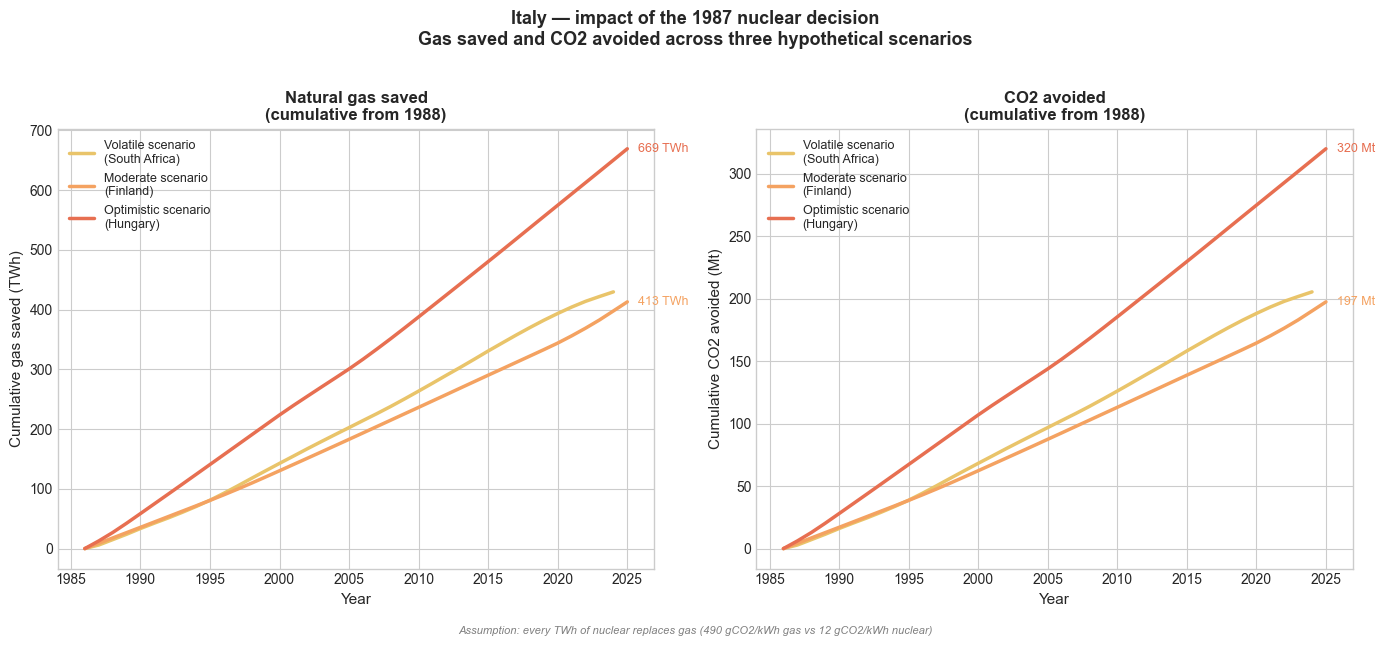

2026-05-07 17:55:29,029 — INFO — Chart saved to plots/


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scenarios = {
    'South Africa': {'label': 'Volatile scenario\n(South Africa)', 'color': '#E9C46A'},
    'Finland':      {'label': 'Moderate scenario\n(Finland)',       'color': '#F4A261'},
    'Hungary':      {'label': 'Optimistic scenario\n(Hungary)',     'color': '#E76F51'},
}

# --- Left chart: cumulative gas saved over time ---
ax1 = axes[0]

for scenario, props in scenarios.items():
    df_b = benchmarks_twh[scenario]
    df_calc = df_italy[['year','nuclear_twh']].merge(df_b, on='year', how='left')
    df_calc['gas_saved'] = (df_calc['twh_smooth'] - df_calc['nuclear_twh']).clip(lower=0)
    df_calc['gas_cumulative'] = df_calc['gas_saved'].cumsum()

    ax1.plot(df_calc['year'], df_calc['gas_cumulative'],
             color=props['color'], linewidth=2.5, label=props['label'])

    last = df_calc.iloc[-1]
    ax1.annotate(f"{last['gas_cumulative']:.0f} TWh",
                xy=(last['year'], last['gas_cumulative']),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, color=props['color'], va='center')

ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Cumulative gas saved (TWh)', fontsize=11)
ax1.set_title('Natural gas saved\n(cumulative from 1988)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)

# --- Right chart: cumulative CO2 avoided over time ---
ax2 = axes[1]

for scenario, props in scenarios.items():
    df_b = benchmarks_twh[scenario]
    df_calc = df_italy[['year','nuclear_twh']].merge(df_b, on='year', how='left')
    df_calc['gas_saved'] = (df_calc['twh_smooth'] - df_calc['nuclear_twh']).clip(lower=0)
    df_calc['co2_avoided'] = df_calc['gas_saved'] * 1e9 * CO2_DIFF / 1e12
    df_calc['co2_cumulative'] = df_calc['co2_avoided'].cumsum()

    ax2.plot(df_calc['year'], df_calc['co2_cumulative'],
             color=props['color'], linewidth=2.5, label=props['label'])

    last = df_calc.iloc[-1]
    ax2.annotate(f"{last['co2_cumulative']:.0f} Mt",
                xy=(last['year'], last['co2_cumulative']),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, color=props['color'], va='center')

ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Cumulative CO2 avoided (Mt)', fontsize=11)
ax2.set_title('CO2 avoided\n(cumulative from 1988)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

# Methodological note
fig.text(0.5, -0.02,
         'Assumption: every TWh of nuclear replaces gas (490 gCO2/kWh gas vs 12 gCO2/kWh nuclear)',
         ha='center', fontsize=8, color='gray', style='italic')

plt.suptitle('Italy — impact of the 1987 nuclear decision\nGas saved and CO2 avoided across three hypothetical scenarios',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../plots/06_italy_co2_gas_impact.png', dpi=150, bbox_inches='tight')
plt.show()
logger.info("Chart saved to plots/")

## 6. Realistic Scenario — Montalto di Castro

Rather than a scaled benchmark, this scenario is grounded in documented historical data. The Montalto di Castro plant (2 × 982 MWe BWR) was **80% complete in February 1988** when construction was halted following the referendum. Parameters — installed capacity, load factor (75%), decommissioning schedule, and a post-Fukushima maintenance adjustment — are sourced from Wikipedia and the World Nuclear Association. This is a conservative estimate, not an optimistic one.

In [59]:
# Parameters based on documented historical data
# Source: Wikipedia, World Nuclear Association, IAEA

# Installed capacity — gradual scenario (MWe)
CAORSO_MW        = 860    # already operational
TRINO_MW         = 260    # already operational
MONTALTO_1_MW    = 982    # 80% complete in 1988
MONTALTO_2_MW    = 982    # 80% complete in 1988

# Average European load factor historically ~75%
LOAD_FACTOR = 0.75

# TWh produced per year per installed capacity
# Formula: MW * hours/year * load_factor / 1_000_000
def twh_per_year(mw, load_factor=LOAD_FACTOR):
    return mw * 8760 * load_factor / 1_000_000

# Production per plant
twh_caorso     = twh_per_year(CAORSO_MW)
twh_trino      = twh_per_year(TRINO_MW)
twh_montalto_1 = twh_per_year(MONTALTO_1_MW)
twh_montalto_2 = twh_per_year(MONTALTO_2_MW)

logger.info("=== Estimated annual output per plant ===")
logger.info(f"Caorso (860 MWe):           {twh_caorso:.1f} TWh/year")
logger.info(f"Trino (260 MWe):            {twh_trino:.1f} TWh/year")
logger.info(f"Montalto unit 1 (982 MWe):  {twh_montalto_1:.1f} TWh/year")
logger.info(f"Montalto unit 2 (982 MWe):  {twh_montalto_2:.1f} TWh/year")
logger.info(f"Total with Montalto only: {twh_caorso+twh_trino+twh_montalto_1+twh_montalto_2:.1f} TWh/year")

# Build the year-by-year trajectory
import numpy as np

years = list(range(1986, 2025))
production = []

for year in years:
    if year == 1986:
        p = df_italy[df_italy['year'] == year]['nuclear_twh'].values
        production.append(float(p[0]) if len(p) > 0 else 8.76)
    elif year == 1987:
        production.append(twh_caorso + twh_trino)
    elif year <= 1989:
        # Transition: Caorso and Trino still operational
        # Montalto in final construction phase
        p = twh_caorso + twh_trino
        # Gradual ramp-up to Montalto 1 completion
        ramp = (year - 1987) / 3
        p += twh_montalto_1 * ramp
        production.append(p)

    elif year == 1990:
        # Montalto unit 1 fully operational
        production.append(twh_caorso + twh_trino + twh_montalto_1)

    elif year == 1991:
        # Montalto unit 2 operational
        production.append(twh_caorso + twh_trino + twh_montalto_1 + twh_montalto_2)

    elif year <= 2011:
        p = twh_caorso + twh_trino + twh_montalto_1 + twh_montalto_2
        production.append(p)
    elif year <= 2024:
        p = (twh_caorso + twh_trino + twh_montalto_1 + twh_montalto_2) * 0.85
        production.append(p)
df_scenario = pd.DataFrame({'year': years, 'twh_scenario': production})

logger.info("=== Realistic scenario trajectory ===")
for _, row in df_scenario[df_scenario['year'].isin([1987,1990,1991,2000,2010,2020,2024])].iterrows():
    logger.info(f"  {int(row['year'])}: {row['twh_scenario']:.1f} TWh")

2026-05-07 18:35:51,271 — INFO — === Estimated annual output per plant ===
2026-05-07 18:35:51,271 — INFO — Caorso (860 MWe):           5.7 TWh/year
2026-05-07 18:35:51,272 — INFO — Trino (260 MWe):            1.7 TWh/year
2026-05-07 18:35:51,272 — INFO — Montalto unit 1 (982 MWe):  6.5 TWh/year
2026-05-07 18:35:51,272 — INFO — Montalto unit 2 (982 MWe):  6.5 TWh/year
2026-05-07 18:35:51,273 — INFO — Total with Montalto only: 20.3 TWh/year
2026-05-07 18:35:51,274 — INFO — === Realistic scenario trajectory ===
2026-05-07 18:35:51,275 — INFO —   1987: 7.4 TWh
2026-05-07 18:35:51,275 — INFO —   1990: 13.8 TWh
2026-05-07 18:35:51,276 — INFO —   1991: 20.3 TWh
2026-05-07 18:35:51,276 — INFO —   2000: 20.3 TWh
2026-05-07 18:35:51,276 — INFO —   2010: 20.3 TWh
2026-05-07 18:35:51,277 — INFO —   2020: 17.2 TWh
2026-05-07 18:35:51,277 — INFO —   2024: 17.2 TWh


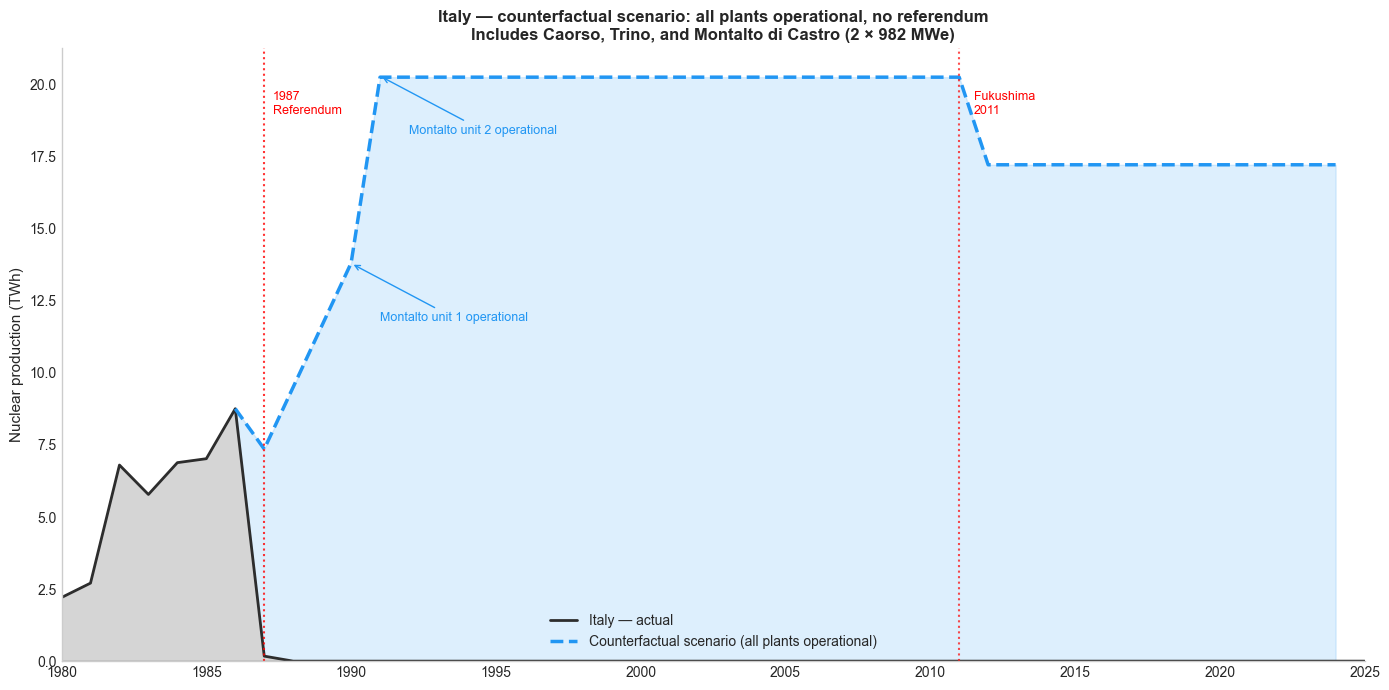

2026-05-07 18:51:20,825 — INFO — Chart saved to plots/


In [62]:
fig, ax1 = plt.subplots(1, 1, figsize=(14, 7))

# Italy actual
df_italy_full = df_merged[df_merged['country'] == 'Italy'].copy()
ax1.fill_between(df_italy_full['year'], df_italy_full['nuclear_twh'],
                 alpha=0.2, color='#2d2d2d')
ax1.plot(df_italy_full['year'], df_italy_full['nuclear_twh'],
         color='#2d2d2d', linewidth=2, label='Italy — actual')

# Counterfactual scenario — from 1987 onwards
df_s = df_scenario[df_scenario['year'] >= 1986]
# Merge i due DataFrame per allineare gli anni
df_fill = df_s.merge(df_italy_full[['year','nuclear_twh']], on='year', how='left')
df_fill['nuclear_twh'] = df_fill['nuclear_twh'].fillna(0)

ax1.fill_between(df_fill['year'], 
                 df_fill['nuclear_twh'],      # limite inferiore = linea nera
                 df_fill['twh_scenario'],      # limite superiore = linea blu
                 alpha=0.15, color='#2196F3')
ax1.plot(df_s['year'], df_s['twh_scenario'],
         color='#2196F3', linewidth=2.5, linestyle='--',
         label='Counterfactual scenario (all plants operational)')

# Annotations
ax1.annotate('Montalto unit 1 operational', xy=(1990, 13.8), xytext=(1991, 11.8),
             arrowprops=dict(arrowstyle='->', color='#2196F3'), fontsize=9, color='#2196F3')
ax1.annotate('Montalto unit 2 operational', xy=(1991, 20.3), xytext=(1992, 18.3),
             arrowprops=dict(arrowstyle='->', color='#2196F3'), fontsize=9, color='#2196F3')

# Referendum line
ax1.axvline(x=1987, color='red', linestyle=':', linewidth=1.5, alpha=0.8)
ax1.text(1987.3, 19, '1987\nReferendum', color='red', fontsize=9)

# Fukushima event
ax1.axvline(x=2011, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax1.text(2011.5, 19, 'Fukushima\n2011', color='red', fontsize=9)


ax1.set_ylabel('Nuclear production (TWh)', fontsize=11)
ax1.set_title('Italy — counterfactual scenario: all plants operational, no referendum\n'
              'Includes Caorso, Trino, and Montalto di Castro (2 × 982 MWe)',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xlim(1980, 2025)
ax1.set_ylim(0)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(False)
plt.tight_layout()
plt.savefig('../plots/05_italy_realistic_scenario.png', dpi=150, bbox_inches='tight')
plt.show()
logger.info("Chart saved to plots/")

## 7. European Validation

To assess whether the realistic scenario is plausible, we compare Italy's hypothetical trajectory against the actual (unscaled) trajectories of comparable European fleets: Belgium, Spain, Sweden, Finland, and Switzerland — all countries that operated a similar number of reactors during the same period. We then compute the resulting nuclear share (%) to show where Italy would have ranked among its European peers.

In [21]:
# European countries with a nuclear fleet comparable to hypothetical Italy
# Belgium, Spain, Sweden, Finland — all with 4-6 reactors in the period
eu_countries = ['Belgium', 'Spain', 'Sweden', 'Finland', 'Switzerland']

# Load factor formula:
# TWh produced / (installed capacity MW * 8760 hours * 0.001)
# The installed capacity column is not in the dataset,
# but we can compute year-on-year growth % to validate our trajectory

query = """
    SELECT country, year, nuclear_twh
    FROM nuclear_generation
    WHERE country IN ('Belgium', 'Spain', 'Sweden', 'Finland', 'Switzerland')
    AND year BETWEEN 1986 AND 2024
    AND nuclear_twh > 0
    ORDER BY country, year
"""
df_eu = pd.read_sql(query, conn)

# For each country compute:
# - value in 1986 (starting point)
# - peak value reached
# - value in 2024
# - % growth from 1986 to peak
results_eu = []
for country in eu_countries:
    df_c = df_eu[df_eu['country'] == country]
    if len(df_c) == 0:
        continue
    val_1986 = df_c[df_c['year'] == 1986]['nuclear_twh'].values
    val_max  = df_c['nuclear_twh'].max()
    val_2024 = df_c[df_c['year'] == 2024]['nuclear_twh'].values
    peak_year = df_c.loc[df_c['nuclear_twh'].idxmax(), 'year']

    results_eu.append({
        'Country': country,
        'TWh 1986': round(float(val_1986[0]), 1) if len(val_1986) > 0 else None,
        'TWh peak': round(val_max, 1),
        'Peak year': int(peak_year),
        'TWh 2024': round(float(val_2024[0]), 1) if len(val_2024) > 0 else None,
    })

df_eu_stats = pd.DataFrame(results_eu)
logger.info("=== European reference countries ===")
display(df_eu_stats)

logger.info(f"Average TWh 1986:  {df_eu_stats['TWh 1986'].mean():.1f}")
logger.info(f"Average TWh peak:  {df_eu_stats['TWh peak'].mean():.1f}")
logger.info(f"Average TWh 2024:  {df_eu_stats['TWh 2024'].mean():.1f}")

2026-05-07 17:55:29,466 — INFO — === European reference countries ===


,Country,TWh 1986,TWh peak,Peak year,TWh 2024
0,Belgium,39.4,50.3,2021,31.2
1,Spain,37.5,63.7,2001,54.5
2,Sweden,70.0,77.5,2004,50.7
3,Finland,18.9,34.3,2023,32.6
4,Switzerland,22.4,27.9,2007,24.0


2026-05-07 17:55:29,469 — INFO — Average TWh 1986:  37.6
2026-05-07 17:55:29,470 — INFO — Average TWh peak:  50.7
2026-05-07 17:55:29,470 — INFO — Average TWh 2024:  38.6


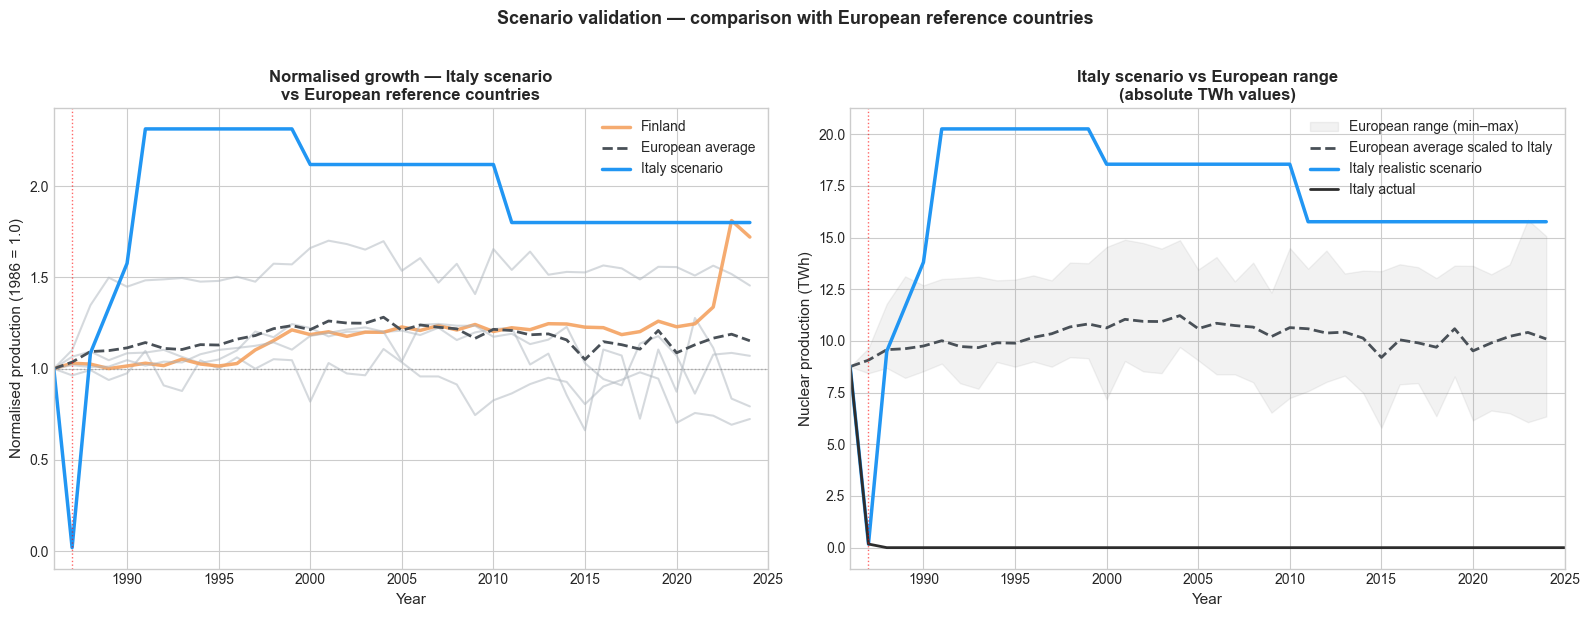

2026-05-07 17:55:29,933 — INFO — Chart saved to plots/


In [22]:
# Normalised growth: each country scaled to 1.0 in 1986
# Allows trajectory comparison independent of scale

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax2 = axes[1]

eu_colors = {
    'Belgium':     '#ADB5BD',
    'Spain':       '#ADB5BD',
    'Sweden':      '#ADB5BD',
    'Finland':     '#F4A261',
    'Switzerland': '#ADB5BD'
}

# --- Left: normalised growth ---
normalised_trajectories = []

for country in eu_countries:
    df_c = df_eu[df_eu['country'] == country].copy()
    val_1986 = df_c[df_c['year'] == 1986]['nuclear_twh'].values
    if len(val_1986) == 0 or val_1986[0] == 0:
        continue
    df_c['normalised'] = df_c['nuclear_twh'] / val_1986[0]
    normalised_trajectories.append(df_c)

    color = eu_colors.get(country, '#ADB5BD')
    thickness = 2.5 if country == 'Finland' else 1.5
    alpha = 0.9 if country == 'Finland' else 0.5
    ax1.plot(df_c['year'], df_c['normalised'],
             color=color, linewidth=thickness, alpha=alpha,
             label=country if country == 'Finland' else '_nolegend_')

# European normalised average
df_all_norm = pd.concat(normalised_trajectories)
avg_normalised = df_all_norm.groupby('year')['normalised'].mean()
ax1.plot(avg_normalised.index, avg_normalised.values,
         color='#495057', linewidth=2, linestyle='--',
         label='European average')

# Italy scenario normalised (base: Italy 1986 = 8.76 TWh)
df_scenario_norm = df_scenario[df_scenario['year'] >= 1986].copy()
df_scenario_norm['normalised'] = df_scenario_norm['twh_scenario'] / 8.76
ax1.plot(df_scenario_norm['year'], df_scenario_norm['normalised'],
         color='#2196F3', linewidth=2.5, linestyle='-',
         label='Italy scenario')

ax1.axvline(x=1987, color='red', linestyle=':', linewidth=1, alpha=0.6)
ax1.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Normalised production (1986 = 1.0)', fontsize=11)
ax1.set_title('Normalised growth — Italy scenario\nvs European reference countries',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xlim(1986, 2025)

# --- Right: Italy scenario with European confidence band ---
# Compute min/max of the normalised European band
band_min = df_all_norm.groupby('year')['normalised'].min()
band_max = df_all_norm.groupby('year')['normalised'].max()

# Convert to absolute TWh for Italy
ax2.fill_between(band_min.index,
                 band_min.values * 8.76,
                 band_max.values * 8.76,
                 alpha=0.1, color='gray',
                 label='European range (min–max)')
ax2.plot(avg_normalised.index, avg_normalised.values * 8.76,
         color='#495057', linewidth=2, linestyle='--',
         label='European average scaled to Italy')
ax2.plot(df_scenario_norm['year'], df_scenario_norm['twh_scenario'],
         color='#2196F3', linewidth=2.5,
         label='Italy realistic scenario')

# Actual line
df_italy_plot = df_merged[
    (df_merged['country'] == 'Italy') &
    (df_merged['year'] >= 1986)
].copy()
ax2.plot(df_italy_plot['year'], df_italy_plot['nuclear_twh'],
         color='#2d2d2d', linewidth=2, label='Italy actual')

ax2.axvline(x=1987, color='red', linestyle=':', linewidth=1, alpha=0.6)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Nuclear production (TWh)', fontsize=11)
ax2.set_title('Italy scenario vs European range\n(absolute TWh values)',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_xlim(1986, 2025)

plt.suptitle('Scenario validation — comparison with European reference countries',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../plots/08_european_scenario_validation.png', dpi=150, bbox_inches='tight')
plt.show()
logger.info("Chart saved to plots/")

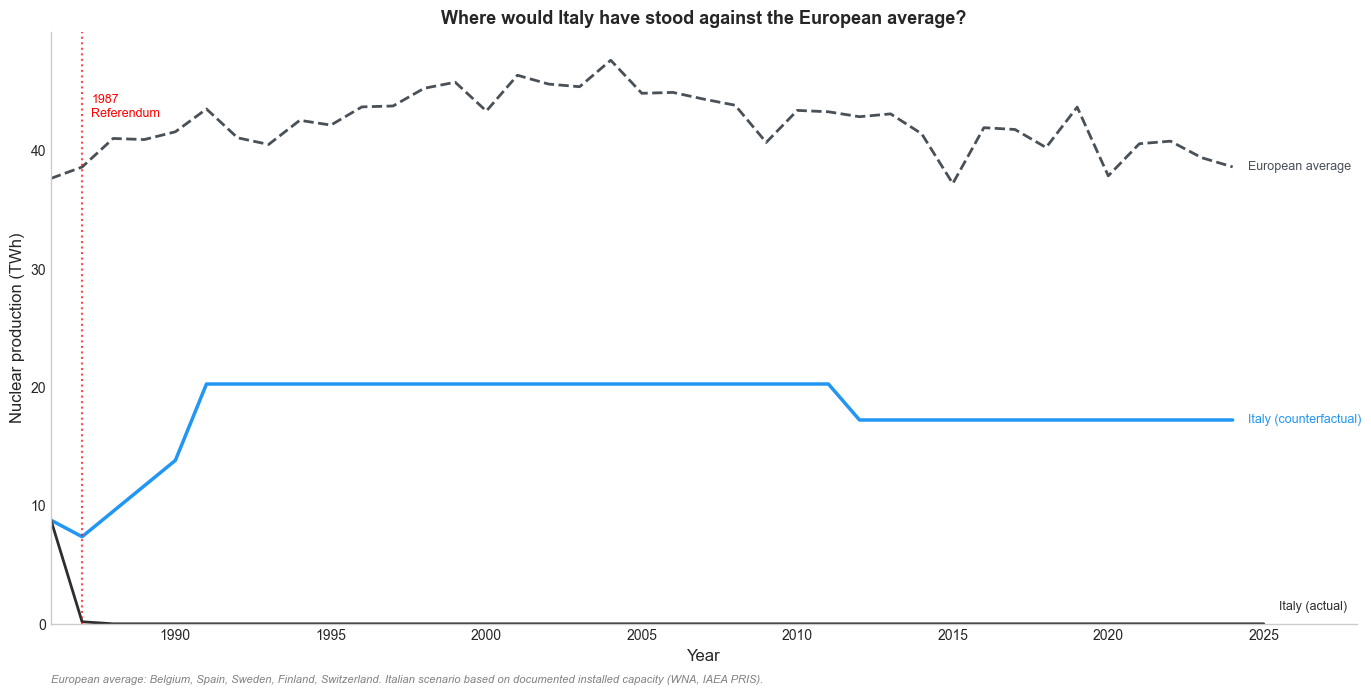

2026-05-07 19:00:22,256 — INFO — Chart saved to plots/


In [70]:
fig, ax = plt.subplots(figsize=(14, 7))

# Media europea
eu_avg_actual = df_eu.groupby('year')['nuclear_twh'].mean()
ax.plot(eu_avg_actual.index, eu_avg_actual.values,
        color='#495057', linewidth=2, linestyle='--')
ax.text(eu_avg_actual.index[-1] + 0.5, eu_avg_actual.values[-1],
        'European average', va='center', fontsize=9, color='#495057')

# Scenario ipotetico Italia
df_s = df_scenario[df_scenario['year'] >= 1986]
ax.plot(df_s['year'], df_s['twh_scenario'],
        color='#2196F3', linewidth=2.5)
ax.text(df_s['year'].iloc[-1] + 0.5, df_s['twh_scenario'].iloc[-1],
        'Italy (counterfactual)', va='center', fontsize=9, color='#2196F3')

# Italia reale
df_italy_plot = df_merged[
    (df_merged['country'] == 'Italy') &
    (df_merged['year'] >= 1986)
].copy()
ax.plot(df_italy_plot['year'], df_italy_plot['nuclear_twh'],
        color='#2d2d2d', linewidth=2)
ax.text(df_italy_plot['year'].iloc[-1] + 0.5, 1.5,
        'Italy (actual)', va='center', fontsize=9, color='#2d2d2d')

# Referendum
ax.axvline(x=1987, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(1987.3, eu_avg_actual.values.max() * 0.9,
        '1987\nReferendum', color='red', fontsize=9)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Nuclear production (TWh)', fontsize=12)
ax.set_title("Where would Italy have stood against the European average?",
             fontsize=13, fontweight='bold')
ax.set_xlim(1986, 2028)
ax.set_ylim(0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

ax.text(0, -0.1,
        'European average: Belgium, Spain, Sweden, Finland, Switzerland. '
        'Italian scenario based on documented installed capacity (WNA, IAEA PRIS).',
        transform=ax.transAxes, fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig('../plots/06_european_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
logger.info("Chart saved to plots/")

In [24]:
query = """
    SELECT n.country, n.year,
           n.nuclear_twh,
           i.nuclear_share_elec
    FROM nuclear_generation n
    LEFT JOIN nuclear_indicators i
        ON n.country = i.country AND n.year = i.year
    WHERE n.country IN ('Belgium', 'Spain', 'Sweden', 'Finland', 'Switzerland')
    AND n.year BETWEEN 1986 AND 2024
    AND n.nuclear_twh > 0
    ORDER BY n.country, n.year
"""
df_eu_share = pd.read_sql(query, conn)

logger.info("=== Nuclear share data availability by country ===")
for country in ['Belgium', 'Spain', 'Sweden', 'Finland', 'Switzerland']:
    df_c = df_eu_share[df_eu_share['country'] == country]
    dati_share = df_c['nuclear_share_elec'].notna().sum()
    logger.info(f"{country}: {dati_share} years with share % data")

logger.info("First rows — Finland:")
display(df_eu_share[df_eu_share['country'] == 'Finland'].head(10))

2026-05-07 17:55:30,291 — INFO — === Nuclear share data availability by country ===
2026-05-07 17:55:30,292 — INFO — Belgium: 39 years with share % data
2026-05-07 17:55:30,293 — INFO — Spain: 39 years with share % data
2026-05-07 17:55:30,294 — INFO — Sweden: 39 years with share % data
2026-05-07 17:55:30,294 — INFO — Finland: 39 years with share % data
2026-05-07 17:55:30,295 — INFO — Switzerland: 39 years with share % data
2026-05-07 17:55:30,295 — INFO — First rows — Finland:


,country,year,nuclear_twh,nuclear_share_elec
39,Finland,1986,18.945263,38.705
40,Finland,1987,19.509474,36.799
41,Finland,1988,19.417894,36.301
42,Finland,1989,18.957895,35.529
43,Finland,1990,19.220000,35.357
44,Finland,1991,19.510000,33.661
45,Finland,1992,19.260000,33.380
46,Finland,1993,19.930000,32.640
47,Finland,1994,19.430000,29.610
48,Finland,1995,19.220000,30.031


In [25]:
# Total Italian electricity production from OWID CSV
df_it_elec = df_owid_full[df_owid_full['country'] == 'Italy'][
    ['year', 'electricity_generation']
].copy()
df_it_elec = df_it_elec[df_it_elec['year'] >= 1986].copy()

# Merge with the hypothetical scenario
df_italy_share = df_scenario.merge(df_it_elec, on='year', how='left')
df_italy_share['share_ipotetica'] = (
    df_italy_share['twh_scenario'] /
    df_italy_share['electricity_generation'] * 100
)

# Italy actual nuclear share
df_italy_real_share = pd.read_sql("""
    SELECT i.year, i.nuclear_share_elec
    FROM nuclear_indicators i
    WHERE i.country = 'Italy'
    AND i.year BETWEEN 1986 AND 2024
""", conn)

logger.info("=== Italy hypothetical nuclear share ===")
for _, row in df_italy_share[
    df_italy_share['year'].isin([1986,1991,1995,2000,2010,2020,2024])
].iterrows():
    logger.info(f"  {int(row['year'])}: {row['share_ipotetica']:.1f}%")

2026-05-07 17:55:30,307 — INFO — === Italy hypothetical nuclear share ===
2026-05-07 17:55:30,307 — INFO —   1986: 4.6%
2026-05-07 17:55:30,308 — INFO —   1991: 9.3%
2026-05-07 17:55:30,308 — INFO —   1995: 8.5%
2026-05-07 17:55:30,309 — INFO —   2000: 6.9%
2026-05-07 17:55:30,309 — INFO —   2010: 6.3%
2026-05-07 17:55:30,309 — INFO —   2020: 5.7%
2026-05-07 17:55:30,310 — INFO —   2024: 5.9%


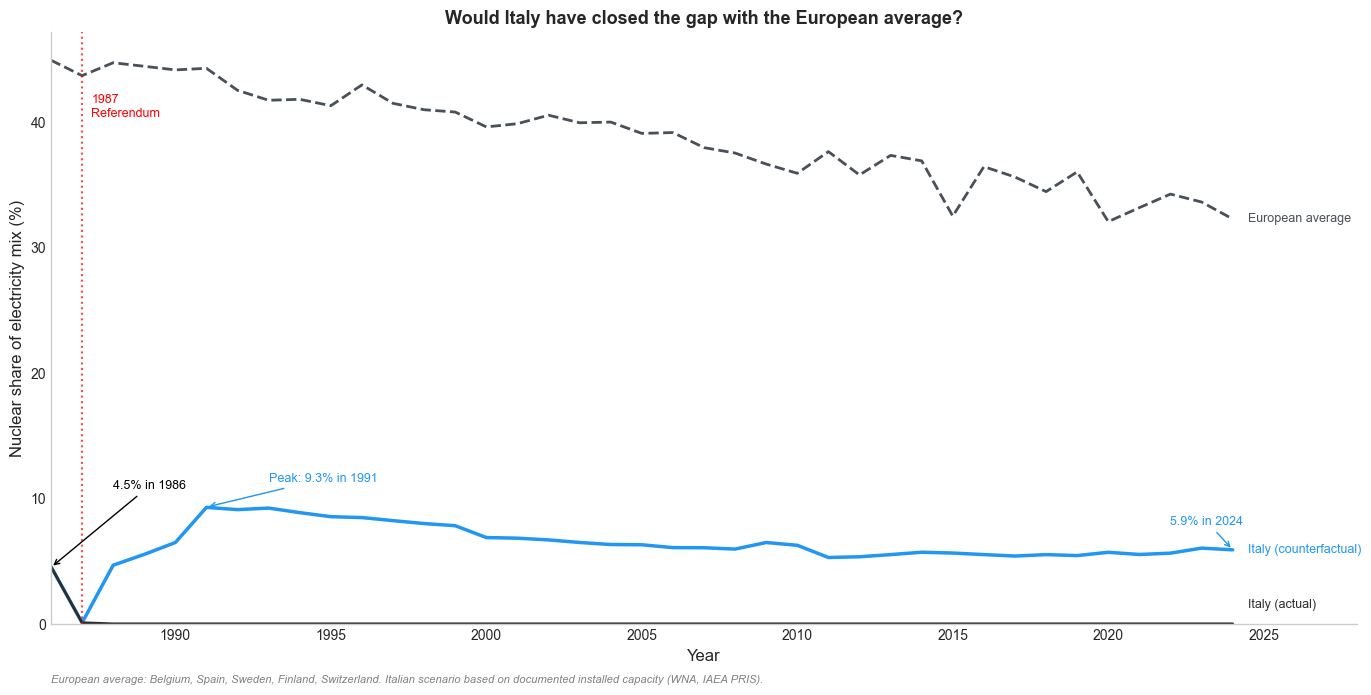

2026-05-07 19:10:28,118 — INFO — Chart saved to plots/


In [76]:
fig, ax = plt.subplots(figsize=(14, 7))

# Media europea
eu_avg_share = df_eu_share.groupby('year')['nuclear_share_elec'].mean()
ax.plot(eu_avg_share.index, eu_avg_share.values,
        color='#495057', linewidth=2, linestyle='--')
ax.text(eu_avg_share.index[-1] + 0.5, eu_avg_share.values[-1],
        'European average', va='center', fontsize=9, color='#495057')

# Italia scenario
ax.plot(df_italy_share['year'],
        df_italy_share['share_ipotetica'].fillna(0),
        color='#2196F3', linewidth=2.5)
ax.text(df_italy_share['year'].iloc[-1] + 0.5,
        df_italy_share['share_ipotetica'].fillna(0).iloc[-1],
        'Italy (counterfactual)', va='center', fontsize=9, color='#2196F3')

# Italia reale
ax.plot(df_italy_real_share['year'],
        df_italy_real_share['nuclear_share_elec'].fillna(0),
        color='#2d2d2d', linewidth=2)
ax.text(df_italy_real_share['year'].iloc[-1] + 0.5, 1.5,
        'Italy (actual)', va='center', fontsize=9, color='#2d2d2d')

# Annotazioni chiave
ax.annotate('4.5% in 1986',
            xy=(1986, 4.5), xytext=(1988, 10.76),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, color='black')
ax.annotate('Peak: 9.3% in 1991',
            xy=(1991, 9.3), xytext=(1993, 11.3),
            arrowprops=dict(arrowstyle='->', color='#2196F3'),
            fontsize=9, color='#2196F3')
ax.annotate('5.9% in 2024',
            xy=(2024, 5.9), xytext=(2022, 7.9),
            arrowprops=dict(arrowstyle='->', color='#2196F3'),
            fontsize=9, color='#2196F3')

# Referendum
ax.axvline(x=1987, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(1987.3, eu_avg_share.values.max() * 0.9,
        '1987\nReferendum', color='red', fontsize=9)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Nuclear share of electricity mix (%)', fontsize=12)
ax.set_title('Would Italy have closed the gap with the European average?',
             fontsize=13, fontweight='bold')
ax.set_xlim(1986, 2028)
ax.set_ylim(0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

ax.text(0, -0.1,
        'European average: Belgium, Spain, Sweden, Finland, Switzerland. '
        'Italian scenario based on documented installed capacity (WNA, IAEA PRIS).',
        transform=ax.transAxes, fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig('../plots/07_nuclear_share_european_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
logger.info("Chart saved to plots/")

## 8. Conclusions

Key quantitative findings from this analysis:

- Completing only Montalto di Castro, Italy would have reached a **maximum nuclear share of ~9.3%** in 1991 — well below the European average of ~40% at the time
- By 2024 the share would have declined to ~6%, confirming nuclear was always a **marginal support source**, not a dominant one
- Between 1988 and 2024, the realistic scenario would have avoided an estimated **642 TWh of gas** and **307 Mt of CO₂**
- Italy's hypothetical trajectory sits in the **lower range of European producers**, consistent with Finland — a country with a comparable installed capacity at the time

These findings are conservative by construction. The counterfactual does not assume any plant beyond those already under construction at the time of the referendum.